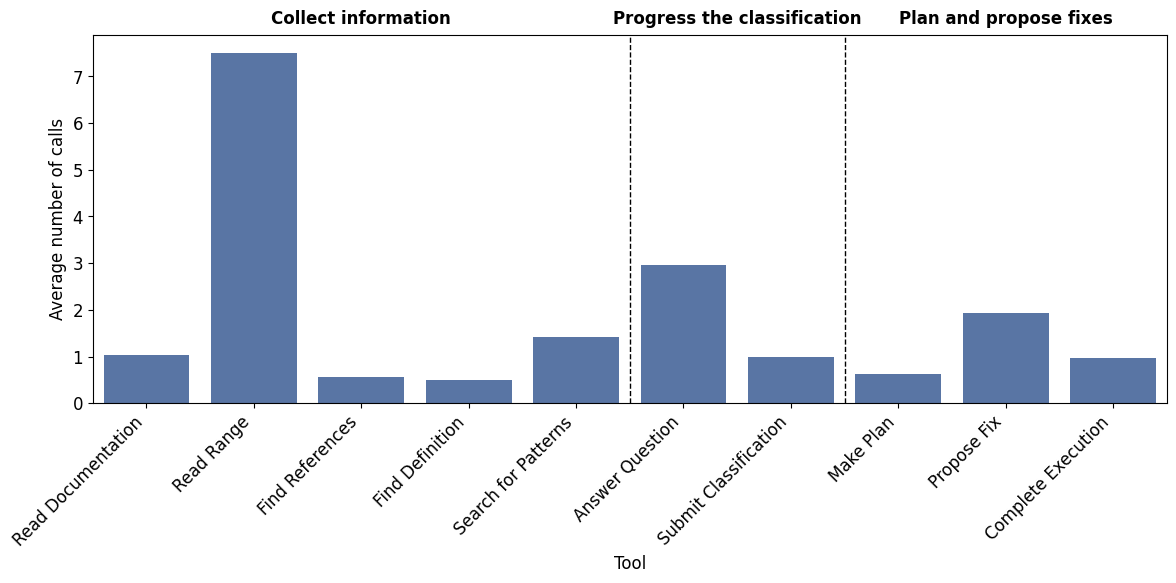

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Average tool calls

evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")

average_calls = [
    evaluation_results_df["tool_calls_read_sonarqube_docu"].mean(),
    evaluation_results_df["tool_calls_read_range"].mean(),
    evaluation_results_df["tool_calls_find_references"].mean(),
    evaluation_results_df["tool_calls_find_definition"].mean(),
    evaluation_results_df["tool_calls_search_for_patterns"].mean(),
    evaluation_results_df["tool_calls_answer_question"].mean(),
    evaluation_results_df["tool_calls_give_final_verdict"].mean(),
    evaluation_results_df["tool_calls_formulate_plan"].mean(),
    evaluation_results_df["tool_calls_write_fix"].mean(),
    evaluation_results_df["tool_calls_goals_accomplished"].mean()
]

tool_names = [
    "Read Documentation", "Read Range", "Find References", "Find Definition", "Search for Patterns",
    "Answer Question", "Submit Classification", "Make Plan", "Propose Fix", "Complete Execution"
]

calls_data = pd.DataFrame({"Tool": tool_names, "Calls": average_calls})
calls_data["Tool"] = pd.Categorical(calls_data["Tool"], categories=tool_names, ordered=True)

plt.rcParams["font.size"] = 12

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Tool", y="Calls", data=calls_data, color="#4c72b0")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool")
plt.ylabel("Average number of calls")

# Add visual group separation
for xpos in [4.5, 6.5]:
    ax.axvline(x=xpos, color="black", linestyle="--", linewidth=1)

group_labels = ["Collect information", "Progress the classification", "Plan and propose fixes"]
group_positions = [(0, 4), (5, 6), (7, 9)] 

ymax = ax.get_ylim()[1]
y_offset = ymax + 0.02 * ymax 

for (start, end), label in zip(group_positions, group_labels):
    xpos = (start + end) / 2
    ax.text(xpos, y_offset, label, ha="center", va="bottom", fontweight="bold")

# Adjust margins so labels are visible
plt.subplots_adjust(bottom=0.2)

plt.tight_layout()
plt.savefig("../evaluation_results/plots/average_tool_calls_comparison.svg", dpi=300)
plt.show()





fixed write_fix average: 1.5227272727272727
unfixed write_fix average: 14.25


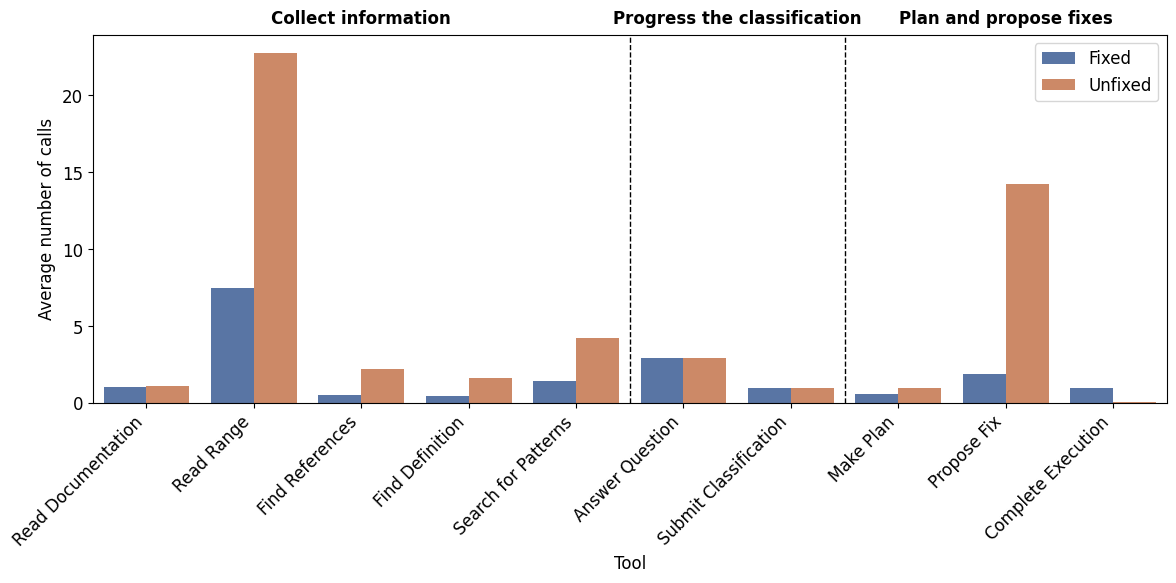

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Average tool calls fixed vs. unfixed

evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")

average_calls_fixed = [
    evaluation_results_df["tool_calls_read_sonarqube_docu"].loc[evaluation_results_df["plausibleFix"]].mean(),  
    evaluation_results_df["tool_calls_read_range"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_references"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_definition"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_search_for_patterns"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_answer_question"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_give_final_verdict"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_formulate_plan"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_write_fix"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_goals_accomplished"].loc[evaluation_results_df["plausibleFix"]].mean(),
]

print("fixed write_fix average: " + str(average_calls_fixed[8]))

average_calls_unfixed = [
    evaluation_results_df["tool_calls_read_sonarqube_docu"].loc[~evaluation_results_df["plausibleFix"]].mean(),  
    evaluation_results_df["tool_calls_read_range"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_references"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_definition"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_search_for_patterns"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_answer_question"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_give_final_verdict"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_formulate_plan"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_write_fix"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_goals_accomplished"].loc[~evaluation_results_df["plausibleFix"]].mean(),
]


print("unfixed write_fix average: " + str(average_calls_unfixed[8]))

tool_names = [
    "Read Documentation", "Read Range", "Find References", "Find Definition", "Search for Patterns",
    "Answer Question", "Submit Classification", "Make Plan", "Propose Fix", "Complete Execution"
]

calls_data = pd.DataFrame({"Tool": tool_names, "Fixed": average_calls, "Unfixed": average_calls_unfixed})
calls_data["Tool"] = pd.Categorical(calls_data["Tool"], categories=tool_names, ordered=True)


plt.rcParams["font.size"] = 12

plt.figure(figsize=(12, 6))

ax = sns.barplot(x="Tool", y="value", hue="variable",
                 data=pd.melt(calls_data, id_vars=["Tool"], value_vars=["Fixed", "Unfixed"]),
                 palette=["#4c72b0", "#dd8456"])


plt.legend()

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool")
plt.ylabel("Average number of calls")

# Add visual group separation
for xpos in [4.5, 6.5]:
    ax.axvline(x=xpos, color="black", linestyle="--", linewidth=1)

group_labels = ["Collect information", "Progress the classification", "Plan and propose fixes"]
group_positions = [(0, 4), (5, 6), (7, 9)]  

ymax = ax.get_ylim()[1]
y_offset = ymax + 0.02 * ymax 

for (start, end), label in zip(group_positions, group_labels):
    xpos = (start + end) / 2
    ax.text(xpos, y_offset, label, ha="center", va="bottom", fontweight="bold")

plt.subplots_adjust(bottom=0.2)

plt.tight_layout()
plt.savefig("../evaluation_results/plots/average_tool_calls_comparison_fixed_unfixed.svg", dpi=300)
plt.show()



3.179881832172544


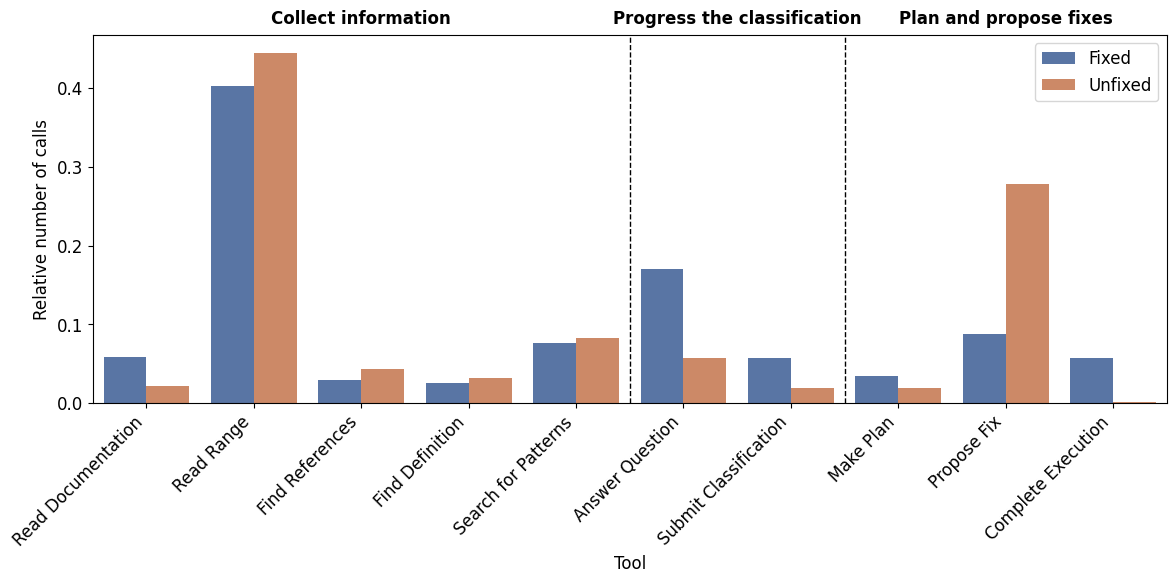

In [3]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Relative tool calls fixed vs. unfixed

evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")

average_calls_fixed = [
    evaluation_results_df["tool_calls_read_sonarqube_docu"].loc[evaluation_results_df["plausibleFix"]].mean(),  
    evaluation_results_df["tool_calls_read_range"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_references"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_definition"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_search_for_patterns"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_answer_question"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_give_final_verdict"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_formulate_plan"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_write_fix"].loc[evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_goals_accomplished"].loc[evaluation_results_df["plausibleFix"]].mean(),
]

total_calls_fixed = sum(average_calls_fixed)
relative_calls_fixed = [call / total_calls_fixed for call in average_calls_fixed]

average_calls_unfixed = [
    evaluation_results_df["tool_calls_read_sonarqube_docu"].loc[~evaluation_results_df["plausibleFix"]].mean(),  
    evaluation_results_df["tool_calls_read_range"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_references"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_find_definition"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_search_for_patterns"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_answer_question"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_give_final_verdict"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_formulate_plan"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_write_fix"].loc[~evaluation_results_df["plausibleFix"]].mean(),
    evaluation_results_df["tool_calls_goals_accomplished"].loc[~evaluation_results_df["plausibleFix"]].mean(),
]

total_calls_unfixed = sum(average_calls_unfixed)
relative_calls_unfixed = [call / total_calls_unfixed for call in average_calls_unfixed]

print(relative_calls_unfixed[8] / relative_calls_fixed[8])

tool_names = [
    "Read Documentation", "Read Range", "Find References", "Find Definition", "Search for Patterns",
    "Answer Question", "Submit Classification", "Make Plan", "Propose Fix", "Complete Execution"
]

calls_data = pd.DataFrame({"Tool": tool_names, "Fixed": relative_calls_fixed, "Unfixed": relative_calls_unfixed})
calls_data["Tool"] = pd.Categorical(calls_data["Tool"], categories=tool_names, ordered=True)


plt.rcParams["font.size"] = 12

plt.figure(figsize=(12, 6))

ax = sns.barplot(x="Tool", y="value", hue="variable",
                 data=pd.melt(calls_data, id_vars=["Tool"], value_vars=["Fixed", "Unfixed"]),
                 palette=["#4c72b0", "#dd8456"])


plt.legend()

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool")
plt.ylabel("Relative number of calls")

# Add visual group separation
for xpos in [4.5, 6.5]:
    ax.axvline(x=xpos, color="black", linestyle="--", linewidth=1)

group_labels = ["Collect information", "Progress the classification", "Plan and propose fixes"]
group_positions = [(0, 4), (5, 6), (7, 9)] 

ymax = ax.get_ylim()[1]
y_offset = ymax + 0.02 * ymax 

for (start, end), label in zip(group_positions, group_labels):
    xpos = (start + end) / 2
    ax.text(xpos, y_offset, label, ha="center", va="bottom", fontweight="bold")

plt.subplots_adjust(bottom=0.2)

plt.tight_layout()
plt.savefig("../evaluation_results/plots/relative_tool_calls_comparison_fixed_unfixed.svg", dpi=300)
plt.show()